This notebook aggregates the individual taxi trips into hourly taxi demand per pickup location.

In [115]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
data = pl.read_parquet("../data/02_merged_data.parquet").rename({"trip_start": "bin_15m", 'pickup_community_area': 'community_area', 'pickup_census_tract': 'census_tract'})
display(data.shape)
display(data.head())

(13505728, 57)

trip_id,taxi_id,bin_15m,trip_end,trip_seconds,trip_miles,census_tract,dropoff_census_tract,community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,average_speed_mph,hour,day_of_week,month,is_weekend,bin_30min,bin_1h,bin_4h,bin_1d,bin_1w,hour_sin,hour_cos,month_sin,month_cos,date_day,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,temperature_c,rain_mm,snowfall_mm,wind_speed_kmh,temperature_max_c,temperature_min_c,rain,heavy_rain,snow,wind,strong_wind
str,str,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",duration[ms],f64,i64,i64,i64,i64,f64,f64,f64,f64,f64,str,str,f64,f64,f64,f64,f64,i8,i8,i8,bool,"datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]","datetime[ms, America/Chicago]",f64,f64,f64,f64,date,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,f32,f32,f32,f32,f32,f32,i8,i8,i8,i8,i8
"""b92300fa1d10595eccd48c91e9c208…","""35b81d25f9e3f38374fc15fd3f7608…",2024-01-01 00:30:00 CST,2024-01-01 00:58:30 CST,28m 30s,17.11,null,null,76,28,42.25,5.0,0.0,0.0,47.75,"""credit card""","""chicago independents""",41.980264,-87.913625,41.874005,-87.663518,36.021053,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""63026182c0fcc8f9b31f9ff7d4e127…","""8dd990653cc2793d96b80ae45e928a…",2024-01-01 00:30:00 CST,2024-01-01 00:34:51 CST,4m 51s,1.17,null,null,24,28,9.0,2.22,0.0,0.0,11.22,"""mobile""","""sun taxi""",41.901207,-87.676356,41.874005,-87.663518,14.474227,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""334418299036d702f319fd67a77ac0…","""552720f76dd5338d0cf254f8eb4045…",2024-01-01 00:30:00 CST,2024-01-01 00:52:52 CST,22m 52s,7.31,null,null,28,3,18.31,4.26,0.0,0.0,22.57,"""mobile""","""choice taxi association""",41.874005,-87.663518,41.965812,-87.655879,19.180758,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""cf7f27241774e1e061d6116b766e94…","""1b9ab0532482023ae1a4cd4364c4e4…",2024-01-01 00:00:00 CST,2024-01-01 00:07:09 CST,7m 9s,1.9,null,null,6,7,8.0,2.0,0.0,1.0,11.5,"""credit card""","""chicago independents""",41.944227,-87.655998,41.922686,-87.649489,15.944056,0,1,1,false,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1
"""6c69addaefe1d4f8746d3a9a59978f…","""7d8179131ea9952793af4cda8635e9…",2024-01-01 00:45:00 CST,2024-01-01 00:54:15 CST,9m 15s,0.35,null,null,8,8,6.25,3.0,0.0,1.0,10.75,"""credit card""","""5 star taxi""",41.899602,-87.633308,41.899602,-87.633308,2.27027,0,1,1,false,2024-01-01 00:30:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,2024-01-01 00:00:00 CST,0.0,1.0,0.5,0.866025,2024-01-01,0,0,0,0,0,0,1,1,1,1,0.35,0.0,0.07,30.449274,2.5,-4.6,0,0,0,0,1


# Trip Aggregation
We previously aggregated a lot of data for the temporal spatial analysis. To use this we do the following:
1. Create a list of trips for census tract and community level
2. Aggregate the lists to census tract/community and 1h buckets
3. Select the additional data and drop duplicates
4. Merge both datasets

We keep in mind, that the census tract includes a lot of missing values, therefore we must drop the missing records first. The result is that we have less than half of the records for the census tract aggregation.

In [117]:
print("Total number of records:", data.shape[0])

Total number of records: 13505728


## Census tract

In [118]:

print("\n--- Census tracts ---")
trips_census = data.select(['census_tract', 'bin_1h'])
display(trips_census.head(2))
print("Number of unique census tracts:", trips_census['census_tract'].n_unique())
print("Number of missing values in census tracts:", trips_census['census_tract'].null_count())
print("Percentage of missing values in census tracts:", round(trips_census['census_tract'].null_count() / trips_census.shape[0] * 100, 2), "%")
trips_census = trips_census.drop_nulls()
print("Number of records after dropping missing values in census tracts:", trips_census.shape[0])


--- Census tracts ---


census_tract,bin_1h
i64,"datetime[ms, America/Chicago]"
null,2024-01-01 00:00:00 CST
null,2024-01-01 00:00:00 CST


Number of unique census tracts: 474
Number of missing values in census tracts: 7399844
Percentage of missing values in census tracts: 54.79 %
Number of records after dropping missing values in census tracts: 6105884


The data looks the following after aggregation:

In [119]:
trips_census_agg = trips_census.group_by(['census_tract', 'bin_1h']).agg(pl.len().alias('trip_count')).sort('bin_1h')
display(trips_census_agg.head(2))

print('Number of bins (unique bin_1h values):', trips_census_agg['bin_1h'].n_unique())

census_tract,bin_1h,trip_count
i64,"datetime[ms, America/Chicago]",u32
17031071500,2024-01-01 00:00:00 CST,1
17031980100,2024-01-01 00:00:00 CST,2


Number of bins (unique bin_1h values): 19443


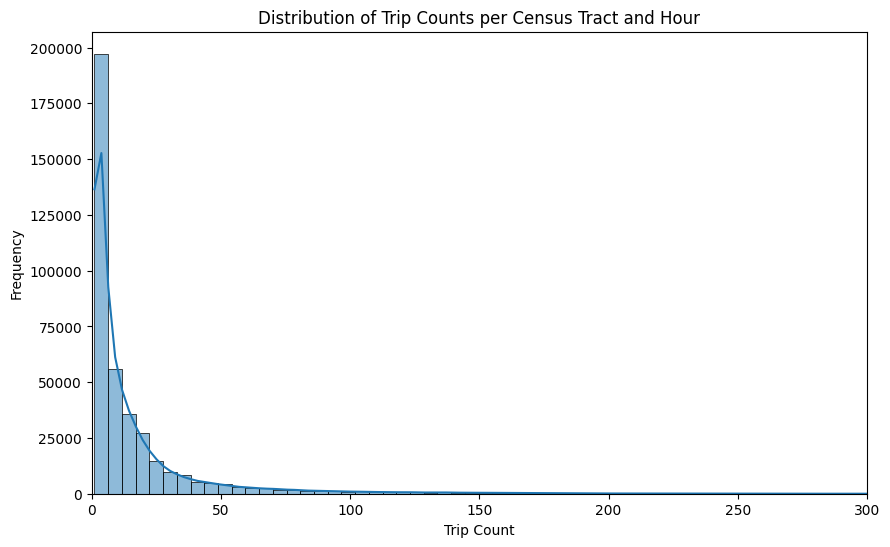

In [120]:
# plot distribution of trip counts
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(trips_census_agg['trip_count'], bins=100, kde=True, ax=ax)
ax.set_title('Distribution of Trip Counts per Census Tract and Hour')
ax.set_xlabel('Trip Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
plt.show()

## Community area

In [121]:
print("\n--- Community areas ---")
trips_community = data.select(['community_area', 'bin_1h'])
display(trips_community.head(2))
print("Number of unique community areas:", trips_community['community_area'].n_unique())
print("Number of missing values in community areas:", trips_community['community_area'].null_count())
print("Percentage of missing values in community areas:", round(trips_community['community_area'].null_count() / trips_community.shape[0] * 100, 2), "%")
trips_community = trips_community.drop_nulls()
print("Number of records after dropping missing values in community areas:", trips_community.shape[0])


--- Community areas ---


community_area,bin_1h
i64,"datetime[ms, America/Chicago]"
76,2024-01-01 00:00:00 CST
24,2024-01-01 00:00:00 CST


Number of unique community areas: 77
Number of missing values in community areas: 0
Percentage of missing values in community areas: 0.0 %
Number of records after dropping missing values in community areas: 13505728


In [122]:
trips_community_agg = trips_community.group_by(['community_area', 'bin_1h']).agg(pl.len().alias('trip_count')).sort('bin_1h')
display(trips_community_agg.head(2))

community_area,bin_1h,trip_count
i64,"datetime[ms, America/Chicago]",u32
38,2024-01-01 00:00:00 CST,1
43,2024-01-01 00:00:00 CST,1


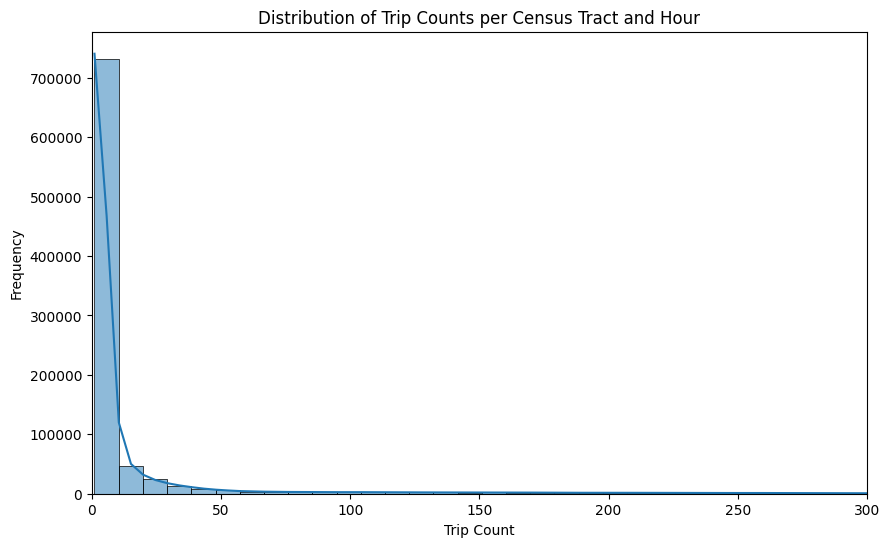

In [123]:
# plot distribution of trip counts
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(trips_community_agg['trip_count'], bins=100, kde=True, ax=ax)
ax.set_title('Distribution of Trip Counts per Census Tract and Hour')
ax.set_xlabel('Trip Count')
ax.set_ylabel('Frequency')
ax.set_xlim(0, 300)
plt.show()

# Additional data
As we already merged the additional data previously, we can now just select it, drop duplicates and merge it back in.

## Previously aggregated data
Other irrelevant location columns are dropped. Furthermore columns which are duplicate are also dropped, e.g. is_weekend is already included as DayOfWeek_Saturday/Sunday. Below you can see the selected columns.

In [124]:
data.columns

['trip_id',
 'taxi_id',
 'bin_15m',
 'trip_end',
 'trip_seconds',
 'trip_miles',
 'census_tract',
 'dropoff_census_tract',
 'community_area',
 'dropoff_community_area',
 'fare_usd',
 'tips_usd',
 'tolls_usd',
 'extras_usd',
 'trip_total_usd',
 'payment_type',
 'company',
 'pickup_lat',
 'pickup_lon',
 'dropoff_lat',
 'dropoff_lon',
 'average_speed_mph',
 'hour',
 'day_of_week',
 'month',
 'is_weekend',
 'bin_30min',
 'bin_1h',
 'bin_4h',
 'bin_1d',
 'bin_1w',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'date_day',
 'DayOfWeek_Friday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'BankHoliday',
 'CorporateHoliday',
 'CityHoliday',
 'StateHoliday',
 'temperature_c',
 'rain_mm',
 'snowfall_mm',
 'wind_speed_kmh',
 'temperature_max_c',
 'temperature_min_c',
 'rain',
 'heavy_rain',
 'snow',
 'wind',
 'strong_wind']

In [125]:
additional_data = data.select([
 'bin_1h',
 'hour_sin',
 'hour_cos',
 'month_sin',
 'month_cos',
 'DayOfWeek_Friday',
 'DayOfWeek_Saturday',
 'DayOfWeek_Sunday',
 'DayOfWeek_Thursday',
 'DayOfWeek_Tuesday',
 'DayOfWeek_Wednesday',
 'BankHoliday',
 'CorporateHoliday',
 'CityHoliday',
 'StateHoliday',
 'rain',
 'heavy_rain',
 'snow',
 'wind',
 'strong_wind',
 'temperature_c',
 'temperature_max_c',
 'temperature_min_c',]).unique(subset=['bin_1h'])
additional_data.head(2)

bin_1h,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
"datetime[ms, America/Chicago]",f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
2024-02-12 10:00:00 CST,0.5,-0.866025,0.866025,0.5,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,2.35,4.25,-2.4
2024-09-11 02:00:00 CDT,0.5,0.866025,-1.0,-1.8370e-16,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,17.4,29.450001,15.2


To ensure that no duplicates are left, we check the bin_1h and calculate some statistics which show that the times are about to match with some gaps.

In [126]:
print('Checking for duplicate bin_1h values in additional_data...')
additional_data_agg = additional_data.group_by(['bin_1h']).agg(pl.len().alias('count')).filter(pl.col('count') > 1)
display(additional_data_agg)

print("\nTotal number of records in additional_data:", additional_data.shape[0])
print("Number of unique days in additional_data:", additional_data['bin_1h'].dt.date().n_unique())
print("Number of days multiplied by 24 hours:", additional_data['bin_1h'].dt.date().n_unique() * 24)

Checking for duplicate bin_1h values in additional_data...


bin_1h,count
"datetime[ms, America/Chicago]",u32



Total number of records in additional_data: 20422
Number of unique days in additional_data: 852
Number of days multiplied by 24 hours: 20448


# Merge Trip aggregation and additional data
Then we merge the data back to the aggregated data.

## Census tract

In [127]:
trips_census_merged = trips_census_agg.join(additional_data, on='bin_1h', how='left')
trips_census_merged.head(2)

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
17031980100,2024-01-01 00:00:00 CST,2,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


There is a small number of incomplete records due to not optimal fitting taxi records and weather data.

In [128]:
print("Missing values in merged data:")
display(trips_census_merged.null_count())

print("\nTotal number of records in census tract merged data:", trips_census_merged.shape[0])
trips_census_merged = trips_census_merged.drop_nulls()
print("Number of records after dropping missing values in merged data:", trips_census_merged.shape[0])

Missing values in merged data:


census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,961,961,961,961,961,961,961,961



Total number of records in census tract merged data: 388310
Number of records after dropping missing values in merged data: 387349


Final census tract dataset:

In [129]:
trips_census_merged.head(2)

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
17031980100,2024-01-01 00:00:00 CST,2,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


## Community area
Same for community area.

In [130]:
trips_community_merged = trips_community_agg.join(additional_data, on='bin_1h', how='left')
trips_community_merged.head(2)

community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
38,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
43,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


There is a small number of incomplete records due to not optimal fitting taxi records and weather data.

In [131]:
print("Missing values in merged data:")
display(trips_community_merged.null_count())

print("\nTotal number of records in community area merged data:", trips_community_merged.shape[0])
trips_community_merged = trips_community_merged.drop_nulls()
print("Number of records after dropping missing values in merged data:", trips_community_merged.shape[0])

Missing values in merged data:


community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2796,2796,2796,2796,2796,2796,2796,2796



Total number of records in community area merged data: 884599
Number of records after dropping missing values in merged data: 881803


Final community area dataset:

In [132]:
trips_community_merged.head(2)

community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32
38,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6
43,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6


# POI
The point of interests were previously stored seperately. They are now loaded and merged on the specific datasets.

In [133]:
poi_community = pl.read_csv("../data/02_poi_per_community_area.csv")
display(poi_community.head(2))
poi_census = pl.read_csv("../data/02_poi_per_census_tract.csv")
display(poi_census.head(2))

community_area,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,i64,i64,i64,i64,i64,i64,i64,i64
1,13,14,96,69,111,22,50,338
2,25,25,82,110,137,7,10,53


census_tract,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,i64,i64,i64,i64,i64,i64,i64,i64
17031000000,0,0,1,22,2,2,8,130
17031010100,0,1,2,12,2,3,0,7


## Census Tract

In [134]:
poi_cols = ['healthcare', 'education', 'amenity', 'leisure', 'shops', 'public_services', 'tourism', 'nature']
trips_census_merged = trips_census_merged.join(poi_census, on='census_tract', how='left').with_columns(pl.col(poi_cols).fill_null(0))
display(trips_census_merged.head(2))
trips_census_merged.write_parquet("../data/03_trips_census_merged.parquet")

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64
17031071500,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,2,2,17,120,11,0,22,121
17031980100,2024-01-01 00:00:00 CST,2,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,0,0,0,0,0,0,0,0


## Community area

In [135]:
trips_community_merged = trips_community_merged.join(poi_community, on='community_area', how='left').with_columns(pl.col(poi_cols).fill_null(0))
display(trips_community_merged.head(2))
trips_community_merged.write_parquet("../data/03_trips_community_merged.parquet")

community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,"datetime[ms, America/Chicago]",u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f32,f32,f32,i64,i64,i64,i64,i64,i64,i64,i64
38,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,14,23,24,53,32,5,20,241
43,2024-01-01 00:00:00 CST,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.35,2.5,-4.6,17,23,42,60,79,9,6,96


In [136]:
display(trips_census_merged.null_count())
display(trips_community_merged.null_count())

census_tract,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


community_area,bin_1h,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Train/Test split & Normalisation
To ensure that there is no data leakage downstream, we already do a train test split here and apply feature scaling (MinMaxScaler).

Steps:
1. Split into train/test
2. Fit the scaler on the training dataset
3. Use the scaler to scale the test set

We only scale the genuinely unbounded features (the POI counts per category and the temperatures) to `[0, 1]`. The cyclic `sin`/`cos` features and the 0/1 flags (day-of-week, holidays, weather) are already on a comparable scale and are left untouched — in particular we do **not** rescale `sin`/`cos`, since scaling each by a different factor would distort the unit-circle geometry the cyclic encoding relies on. The area id and the target `trip_count` are also left in their original form. We do this separately for the census tract and the community area datasets.

> <b>[NOTE]</b> Because the scaler is fit on the training set only, a test record that is hotter/colder than anything in training can fall slightly outside `[0, 1]` — this is expected and we neither clip nor refit.

> <b>[NOTE]</b> Data was split chronologically to prevent leakage. Since census tracts share weather records, a random split would allow the model to cheat by learning patterns from identical weather constellations.

## Census tract

In [137]:
import joblib
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

Path("../models").mkdir(exist_ok=True)

# chronological split (earlier hours train, later hours test) -> no leakage
df = trips_census_merged.sort('bin_1h').drop('bin_1h')
n_test = int(df.height * 0.2)
census_train = df.head(df.height - n_test)
census_test = df.tail(n_test)

# only the unbounded features need scaling; sin/cos and 0/1 flags are already comparable and left as-is
scale_cols = ['healthcare', 'education', 'amenity', 'leisure', 'shops',
              'public_services', 'tourism', 'nature',
              'temperature_c', 'temperature_max_c', 'temperature_min_c']
scaler = MinMaxScaler().fit(census_train.select(scale_cols).to_numpy())  # fit on TRAIN only

train_scaled = scaler.transform(census_train.select(scale_cols).to_numpy())
test_scaled = scaler.transform(census_test.select(scale_cols).to_numpy())
census_train = census_train.with_columns([pl.Series(c, train_scaled[:, i]) for i, c in enumerate(scale_cols)])
census_test = census_test.with_columns([pl.Series(c, test_scaled[:, i]) for i, c in enumerate(scale_cols)])

census_train.write_parquet("../data/03_census_tract_train.parquet")
census_test.write_parquet("../data/03_census_tract_test.parquet")

# store the fitted scaler (+ column order) so new records can be scaled the same way later
joblib.dump({"scaler": scaler, "scale_cols": scale_cols}, "../models/03_census_tract_scaler.joblib")

print(f"train: {census_train.shape}, test: {census_test.shape}")
census_train.head(3)

train: (309880, 32), test: (77469, 32)


census_tract,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
17031071500,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.105263,0.285714,0.153153,0.967742,0.215686,0.0,0.261905,0.295844
17031980100,2,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17031081403,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [139]:
census_train.describe()

statistic,census_tract,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0,309880.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1.7031e10,16.014128,-0.172011,-0.328872,-0.043015,-0.107389,0.161853,0.138347,0.109723,0.158903,0.145834,0.15163,0.029499,0.01264,0.026417,0.009665,0.048341,0.000913,0.008597,0.764244,0.051326,0.632389,0.641675,0.666189,0.154908,0.170796,0.258169,0.156764,0.279255,0.16403,0.129099,0.181357
"""std""",335680.933472,26.977978,0.695669,0.615063,0.720905,0.683313,0.368316,0.345264,0.312545,0.365587,0.35294,0.358662,0.169199,0.111717,0.160371,0.097835,0.214487,0.030206,0.09232,0.424471,0.220663,0.174069,0.197858,0.192142,0.252412,0.260414,0.326311,0.250923,0.342234,0.222243,0.215056,0.289792
"""min""",1.7031e10,1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",1.7031e10,2.0,-0.866025,-0.866025,-0.866025,-0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.506962,0.493931,0.528079,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""50%""",1.7031e10,6.0,-0.258819,-0.5,1.2246e-16,-1.8370e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.654382,0.676937,0.681773,0.052632,0.0,0.054054,0.048387,0.078431,0.0,0.011905,0.022005
"""75%""",1.7032e10,17.0,0.5,6.1232e-17,0.5,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.769861,0.798319,0.825616,0.210526,0.142857,0.486486,0.209677,0.529412,0.375,0.166667,0.264059
"""max""",1.7032e10,532.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Community area

In [138]:
# chronological split (earlier hours train, later hours test) -> no leakage
df = trips_community_merged.sort('bin_1h').drop('bin_1h')
n_test = int(df.height * 0.2)
community_train = df.head(df.height - n_test)
community_test = df.tail(n_test)

# only the unbounded features need scaling; sin/cos and 0/1 flags are already comparable and left as-is
scale_cols = ['healthcare', 'education', 'amenity', 'leisure', 'shops',
              'public_services', 'tourism', 'nature',
              'temperature_c', 'temperature_max_c', 'temperature_min_c']
scaler = MinMaxScaler().fit(community_train.select(scale_cols).to_numpy())  # fit on TRAIN only

train_scaled = scaler.transform(community_train.select(scale_cols).to_numpy())
test_scaled = scaler.transform(community_test.select(scale_cols).to_numpy())
community_train = community_train.with_columns([pl.Series(c, train_scaled[:, i]) for i, c in enumerate(scale_cols)])
community_test = community_test.with_columns([pl.Series(c, test_scaled[:, i]) for i, c in enumerate(scale_cols)])

community_train.write_parquet("../data/03_community_area_train.parquet")
community_test.write_parquet("../data/03_community_area_test.parquet")

# store the fitted scaler (+ column order) so new records can be scaled the same way later
joblib.dump({"scaler": scaler, "scale_cols": scale_cols}, "../models/03_community_area_scaler.joblib")

print(f"train: {community_train.shape}, test: {community_test.shape}")
community_train.head(3)

train: (705443, 32), test: (176360, 32)


community_area,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
i64,u32,f64,f64,f64,f64,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
38,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.134615,0.362069,0.037795,0.126943,0.074879,0.102041,0.082645,0.154345
43,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.163462,0.362069,0.066142,0.145078,0.188406,0.183673,0.024793,0.060311
50,1,0.0,1.0,0.5,0.866025,0,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0.412776,0.370682,0.399015,0.048077,0.068966,0.017323,0.049223,0.028986,0.061224,0.028926,0.054475


In [140]:
community_train.describe()

statistic,community_area,trip_count,hour_sin,hour_cos,month_sin,month_cos,DayOfWeek_Friday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,BankHoliday,CorporateHoliday,CityHoliday,StateHoliday,rain,heavy_rain,snow,wind,strong_wind,temperature_c,temperature_max_c,temperature_min_c,healthcare,education,amenity,leisure,shops,public_services,tourism,nature
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0,705443.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",36.590335,14.969331,-0.065513,-0.195086,0.015701,-0.104504,0.14793,0.139572,0.129612,0.147144,0.144824,0.145793,0.03559,0.019205,0.032469,0.013791,0.045746,0.000921,0.008597,0.766623,0.052524,0.616388,0.632068,0.655377,0.206522,0.284525,0.169119,0.228434,0.220102,0.210843,0.11996,0.15444
"""std""",22.632704,45.039486,0.710574,0.672856,0.729082,0.67622,0.355031,0.346543,0.335876,0.35425,0.351923,0.352899,0.185267,0.137245,0.177242,0.116624,0.208933,0.030341,0.092323,0.42298,0.223082,0.179733,0.206235,0.201269,0.208635,0.20133,0.23887,0.214939,0.232468,0.202783,0.199549,0.207851
"""min""",1.0,1.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",16.0,1.0,-0.707107,-0.866025,-0.866025,-0.866025,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.479115,0.467787,0.505419,0.067308,0.137931,0.029921,0.101036,0.062802,0.102041,0.016529,0.046693
"""50%""",36.0,2.0,-0.258819,-0.258819,1.2246e-16,-1.8370e-16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.641278,0.673203,0.674877,0.134615,0.258621,0.062992,0.158031,0.120773,0.142857,0.03719,0.081712
"""75%""",53.0,6.0,0.707107,0.5,0.866025,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.760033,0.798319,0.824631,0.240385,0.396552,0.168504,0.253886,0.311594,0.244898,0.132231,0.149805
"""max""",77.0,938.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Reusing the scaler

In a modelling/prediction notebook, reload the fitted scaler and apply it to new records (use `transform`, **never** `fit` again):

```python
import joblib

bundle = joblib.load("../models/03_community_area_scaler.joblib")
scaler, scale_cols = bundle["scaler"], bundle["scale_cols"]

# new_records: polars DataFrame containing at least the columns in scale_cols
scaled = scaler.transform(new_records.select(scale_cols).to_numpy())
new_records = new_records.with_columns([pl.Series(c, scaled[:, i]) for i, c in enumerate(scale_cols)])
```